In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from pathlib import Path
import matplotlib.pyplot as plt

In [24]:
x_test = pd.read_csv(Path.cwd().parent / "data/german_credit_test.csv")
y_test = pd.read_csv(Path.cwd().parent / "data/german_credit_test_submission.csv")
test = pd.concat([x_test.reset_index(drop=True), y_test.drop(columns="Id").reset_index(drop=True)], axis=1)
predictions = pd.read_csv("C:/Users/comem/OneDrive/Documents/GitHub/german_credit/Notebooks/prediction_for_comparison.csv")
predictions = predictions.rename(columns={'0': 'Risk'})
predictions.head()


,Unnamed: 0,Id,CheckingStatus,LoanDuration,CreditHistory,LoanPurpose,LoanAmount,ExistingSavings,EmploymentDuration,InstallmentPercent,...,OwnsProperty,Age,InstallmentPlans,Housing,ExistingCreditsCount,Job,Dependents,Telephone,ForeignWorker,Risk
0,0,0,no_checking,9,prior_payments_delayed,car_new,1032,100_to_500,4_to_7,3,...,savings_insurance,41,none,own,1,management_self-employed,1,none,yes,No Risk
1,1,1,less_0,5,all_credits_paid_back,car_new,1523,less_100,unemployed,2,...,real_estate,19,none,rent,1,management_self-employed,1,none,yes,No Risk
2,2,2,no_checking,39,prior_payments_delayed,repairs,7150,500_to_1000,4_to_7,3,...,unknown,52,none,own,2,skilled,1,yes,yes,Risk
3,3,3,0_to_200,15,prior_payments_delayed,furniture,250,500_to_1000,4_to_7,3,...,savings_insurance,24,none,own,2,skilled,2,yes,yes,No Risk
4,4,4,0_to_200,16,prior_payments_delayed,car_new,5551,100_to_500,1_to_4,3,...,car_other,34,none,rent,2,management_self-employed,1,none,yes,No Risk


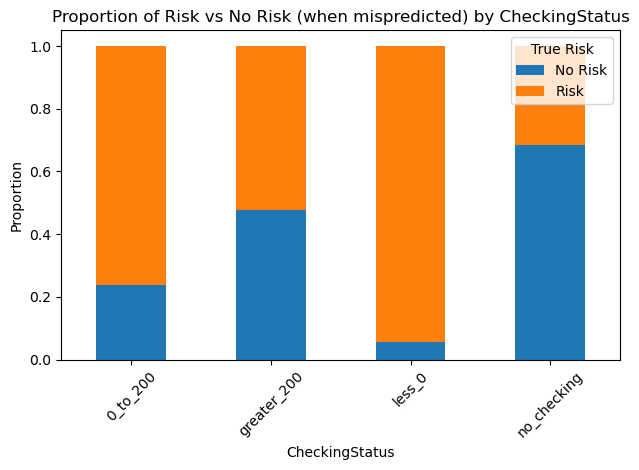

In [16]:

# Rename predicted column (last column in predictions_df) to 'PredictedRisk'
predictions = predictions.rename(columns={predictions.columns[-1]: 'PredictedRisk'})

# Add true labels
predictions['TrueRisk'] = test['Risk']

# Filter mispredictions
mispredictions = predictions[predictions['PredictedRisk'] != predictions['TrueRisk']]

# Choose a feature to analyze
feature = 'CheckingStatus'

# Calculate proportions of 'Risk' vs 'No Risk' per value of the feature
proportions = (mispredictions
               .groupby([feature, 'TrueRisk'])
               .size()
               .unstack(fill_value=0))

proportions_percent = proportions.div(proportions.sum(axis=1), axis=0)

# Plot
proportions_percent.plot(kind='bar', stacked=True)
plt.title(f'Proportion of Risk vs No Risk (when mispredicted) by {feature}')
plt.ylabel('Proportion')
plt.xlabel(feature)
plt.legend(title='True Risk')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

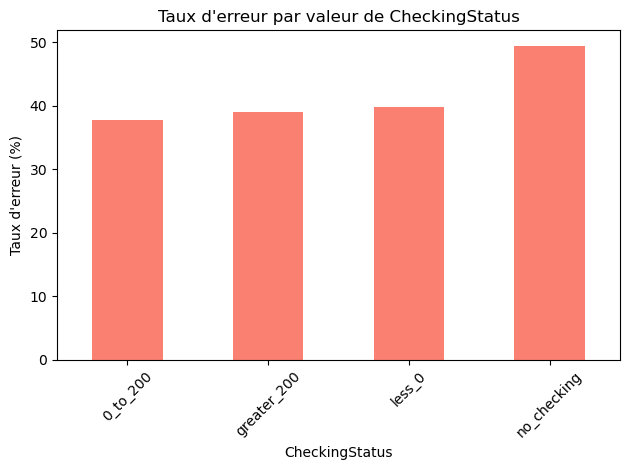

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Assure-toi que les index sont bien alignés
predictions = predictions.reset_index(drop=True)
test = test.reset_index(drop=True)

# Ajouter la colonne TrueRisk
predictions['TrueRisk'] = test['Risk']

# Choisis le feature à analyser
feature = 'CheckingStatus'

# Nombre total d'exemples pour chaque valeur du feature
total_per_feature = predictions.groupby(feature).size()

# Nombre d'erreurs pour chaque valeur du feature
errors_per_feature = predictions[predictions['Risk'] != predictions['TrueRisk']].groupby(feature).size()

# Remplir les valeurs manquantes avec 0
errors_per_feature = errors_per_feature.reindex(total_per_feature.index, fill_value=0)

# Calculer le taux d'erreur en pourcentage
error_rate = (errors_per_feature / total_per_feature) * 100

# Plot
error_rate.plot(kind='bar', color='salmon')
plt.title(f'Taux d\'erreur par valeur de {feature}')
plt.ylabel('Taux d\'erreur (%)')
plt.xlabel(feature)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


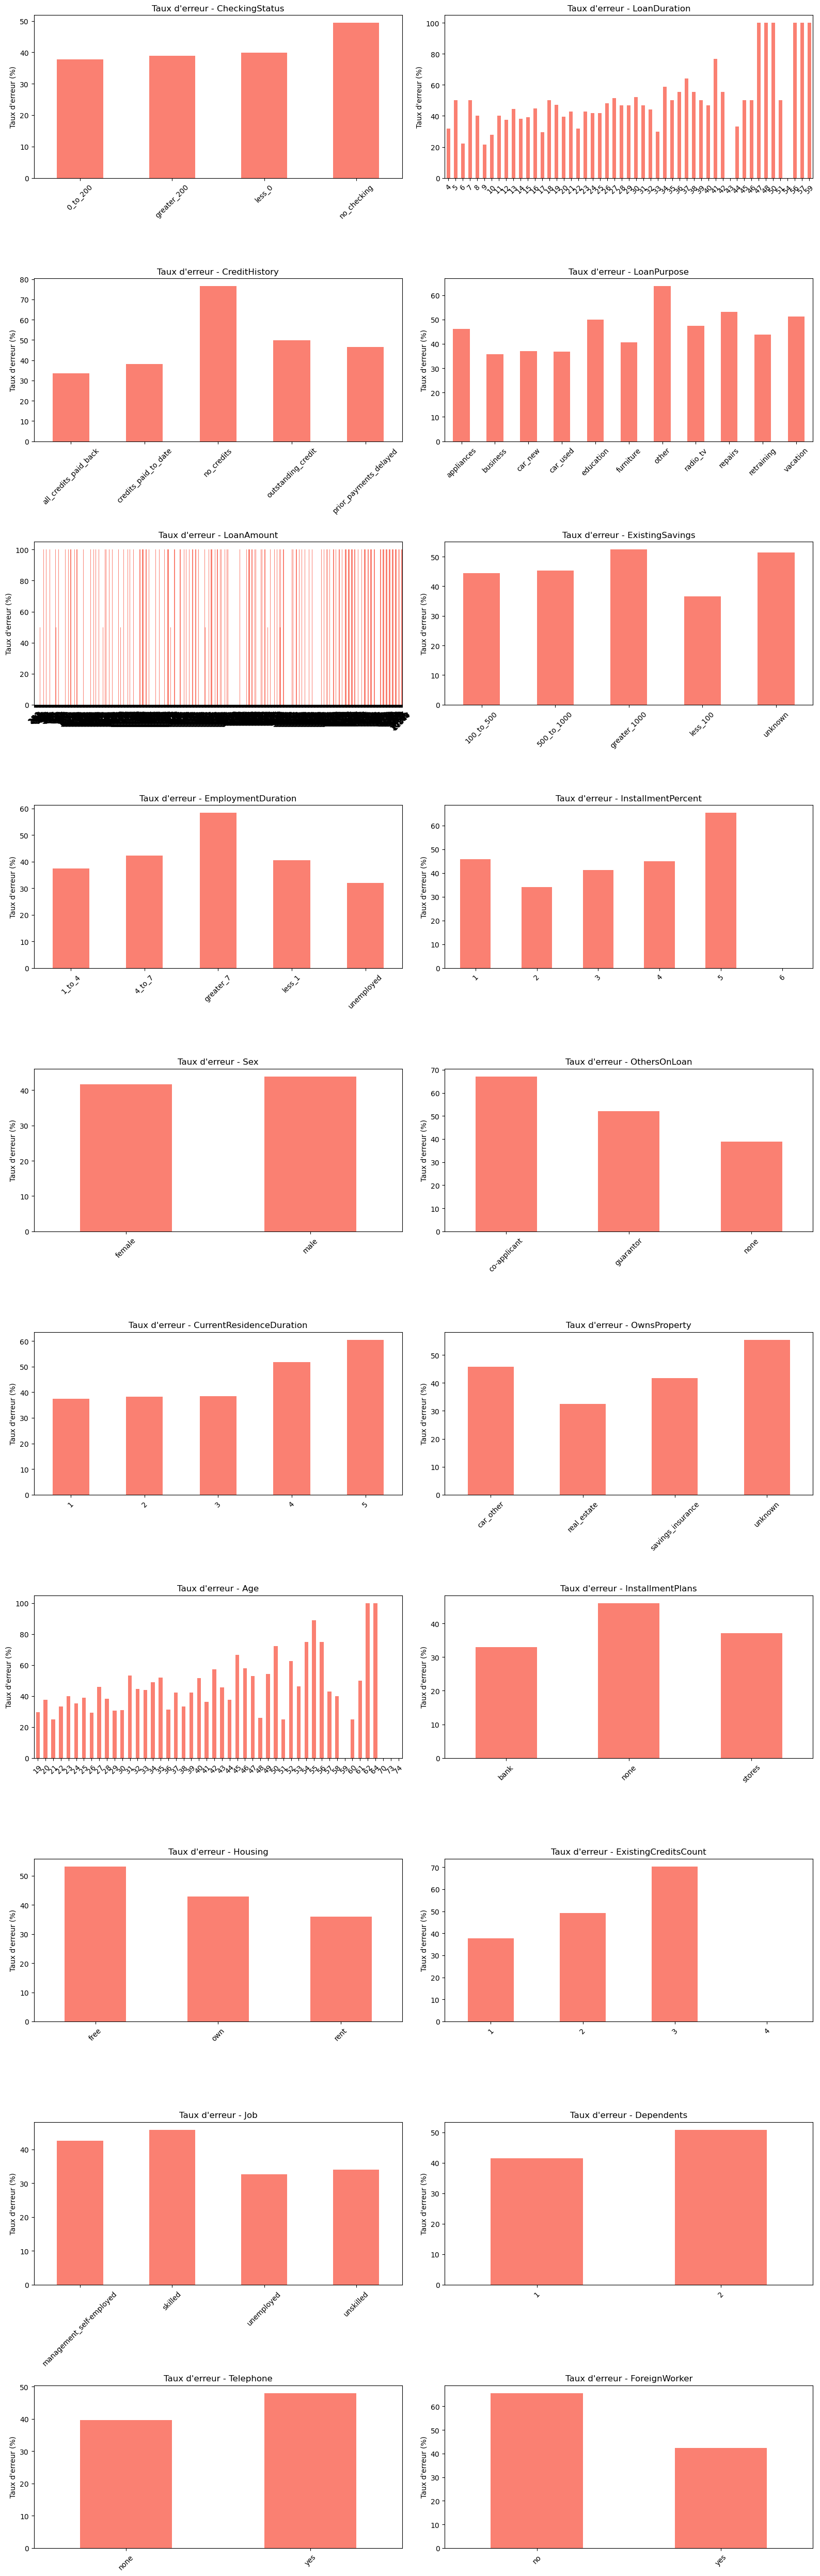

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Réinitialiser les index pour éviter les erreurs d’alignement
predictions = predictions.reset_index(drop=True)
test = test.reset_index(drop=True)

# Ajouter la colonne TrueRisk (valeurs réelles)
predictions['TrueRisk'] = test['Risk']

# Liste des colonnes/features à analyser (on exclut les colonnes techniques)
features = [col for col in predictions.columns if col not in ['Unnamed: 0', 'Id', 'Risk', 'TrueRisk']]

# Configurer la grille des sous-graphiques
n_cols = 2
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

# Créer un graphique pour chaque feature
for i, feature in enumerate(features):
    ax = axes[i]

    # Nombre total d’occurrences pour chaque valeur du feature
    total = predictions.groupby(feature).size()

    # Nombre d’erreurs de prédiction pour chaque valeur du feature
    errors = predictions[predictions['Risk'] != predictions['TrueRisk']].groupby(feature).size()
    errors = errors.reindex(total.index, fill_value=0)

    # Taux d’erreur en %
    error_rate = (errors / total) * 100

    # Affichage du graphique
    error_rate.plot(kind='bar', color='salmon', ax=ax)
    ax.set_title(f"Taux d'erreur - {feature}")
    ax.set_ylabel("Taux d'erreur (%)")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)

# Supprimer les axes vides s’il y en a
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


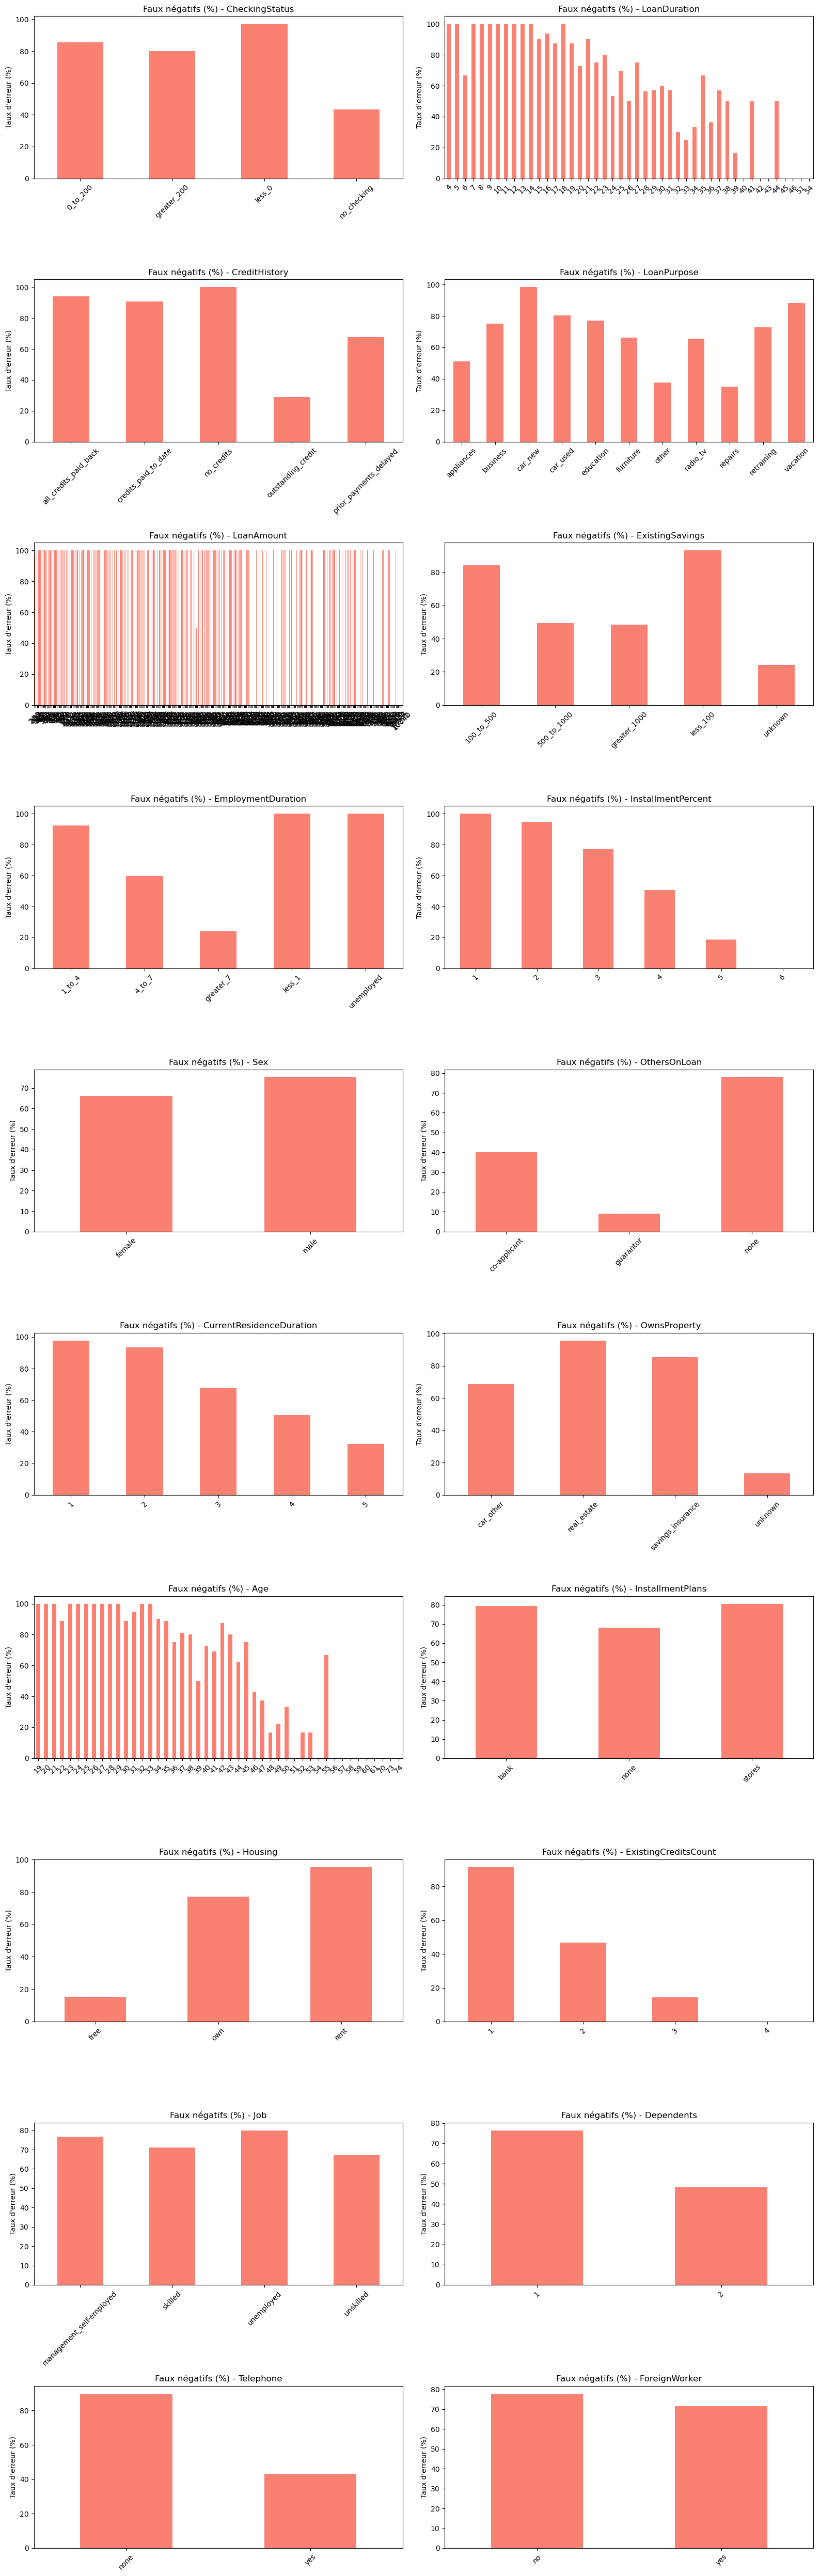

In [28]:
import matplotlib.pyplot as plt

# Réinitialisation propre
predictions = predictions.reset_index(drop=True)
test = test.reset_index(drop=True)

# Ajout de la colonne TrueRisk
predictions['TrueRisk'] = test['Risk']

# Liste des features à analyser
features = [col for col in predictions.columns if col not in ['Unnamed: 0', 'Id', 'Risk', 'TrueRisk']]

# Filtrer les faux négatifs : vrai = Risk, prédiction = No Risk
false_negatives = predictions[
    (predictions['TrueRisk'] == 'Risk') &
    (predictions['Risk'] == 'No Risk')
]

# Nombre de faux négatifs par valeur de feature, comparé au total des cas Risk
n_cols = 2
n_rows = (len(features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]

    # Total de cas "TrueRisk = Risk"
    total = predictions[predictions['TrueRisk'] == 'Risk'].groupby(feature).size()

    # Faux négatifs par valeur du feature
    fn_counts = false_negatives.groupby(feature).size()
    fn_counts = fn_counts.reindex(total.index, fill_value=0)

    # Taux de faux négatifs (%)
    fn_rate = (fn_counts / total) * 100

    # Affichage
    fn_rate.plot(kind='bar', color='salmon', ax=ax)
    ax.set_title(f"Faux négatifs (%) - {feature}")
    ax.set_ylabel("Taux d'erreur (%)")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)

# Supprimer les sous-graphiques inutilisés
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
